<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cads-logo.png?raw=1" style="height: 100px;" align=left>
<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/tf-logo-2.png?raw=1" style="height: 70px;" align=right>
<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/keras-logo.png?raw=1" style="height: 50px;" align=right>

# ANSWER KEY — Day 02: Convolutional Neural Networks

All `# SC` / `# MC` blanks are filled in, with the reasoning written out as comments.

**Two corrections to the original notebook are flagged inline:**

1. Section 3.a.1 / 3.a.2 swap the meaning of `SAME` and `VALID`. In Keras: `VALID` = *no* padding (`O = (I-F)/S + 1`), `SAME` = zero-padded so the size is preserved (`O = ceil(I/S)`).
2. Section 3.1.1.1 (`layers[:0]`, un-batched `img`, un-normalised input) would raise; fixed versions are in place.


# Convolutional Neural Networks

**Pre-requisites:**

1. Python and Pandas Proficiency
2. Supervised Machine Learning
3. Basic Matrix Operations
4. Linear Alegbra, Calculus
5. Artificial Neural Networks and Fully Connected/Dense Layers

## Course Outline

1. [Visual Classification with `Dense` Layers](#1.-Visual-Classification-with-Dense-Layers)
1. [Visual Classification with `Conv2D` Layers](#2.-Visual-Classification-with-Conv2D-Layers)
1. [Components of `ConvNet` Architecture](#3.-Components-of-ConvNet-Architecture)
1. [Variation in Visual Classifier Performance](#4.-Variation-in-Visual-Classifier-Performance)


In [36]:
%load_ext tensorboard

The tensorboard extension is already loaded. To reload it, use:
  %reload_ext tensorboard


In [37]:
%matplotlib inline

# 1. Visual Classification with `Dense` Layers

We will build a visual classifier on `fashion_mnist` dataset. <br>
First , we will make use of purely `Dense` layers and compare its architecture and results to a 2D Convolutional Network  (or `Conv2d`.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_fc_.png?raw=1" style="height: 400px;" align=left>

In [38]:
%%writefile plot_utils.py
import numpy as np
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (6, 6)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']


def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array, true_label[i]
    plt.grid(False)
    plt.xticks(range(10))
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0, 1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color('red')
    thisplot[true_label].set_color('blue')


def plotLoss(history, title, label1, label2):
    hist = history.history
    loss, val_loss = hist['loss'], hist['val_loss']
    epochs = range(1, len(val_loss) + 1)
    plt.plot(epochs, loss, 'bo', label=label1)
    plt.plot(epochs, loss, c='b')
    plt.plot(epochs, val_loss, 'r+', label=label2)
    plt.plot(epochs, val_loss, c='r')
    plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.title(title)
    plt.legend(); plt.show()


def plotAccuracy(history, title, label1, label2):
    hist = history.history
    acc, val_acc = hist['accuracy'], hist['val_accuracy']
    epochs = range(1, len(val_acc) + 1)
    plt.plot(epochs, acc, 'bo', label=label1)
    plt.plot(epochs, acc, c='b')
    plt.plot(epochs, val_acc, 'r+', label=label2)
    plt.plot(epochs, val_acc, c='r')
    plt.xlabel('Epochs'); plt.ylabel('Accuracy'); plt.title(title)
    plt.legend(); plt.show()

Overwriting plot_utils.py


In [39]:
!pip install -q git+https://github.com/tensorflow/docs

  Preparing metadata (setup.py) ... done


In [40]:
import functools

import numpy as np
np.random.seed(42)

import os
import tempfile
import datetime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
plt.rcParams['figure.figsize'] = (8, 6)
colors = plt.rcParams['axes.prop_cycle'].by_key()['color']

from plot_utils import plot_value_array, plotLoss, plotAccuracy

import tensorflow as tf
from tensorflow import keras
tf.keras.backend.clear_session()
from tensorflow.keras import models
from tensorflow.keras import datasets, layers, models, backend
from tensorflow.keras.datasets import cifar10, mnist, fashion_mnist
import tensorflow_docs as tfdocs
import tensorflow_docs.plots
import tensorflow_docs.modeling

In [41]:
# Question: Which type of tensor data are images?

# SC (ANSWER)
# A single image is a 3D TENSOR: (height, width, channels)
#     grayscale -> channels = 1   e.g. fashion_mnist  (28, 28, 1)
#     RGB       -> channels = 3   e.g. cifar10        (32, 32, 3)
# A BATCH of images is therefore a 4D tensor: (samples, height, width, channels)
#     train_images_norm.shape == (60000, 28, 28, 1)
# Keras' default convention here is channels_last -> see backend.image_data_format()


Load `fashion_mnist` data. <br> It consists of a training set of 60,000 examples and a test set of 10,000 examples. Each example is a 28x28 grayscale image, associated with a label from 10 classes. `fashion_mnist`, along with `mnist` are widely used datasets for benchmarking maachine learning models.

Keras API offers an elegant way to split data to `train` and `test` sets. <br>
It will automatically download and cache `fashion_mnist` to disk. <br>

In [42]:
(train_images, train_labels), (test_images, test_labels) = fashion_mnist.load_data()

In [43]:
# Define class names
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

In [44]:
print("Shape: ", train_images[0].shape)
print("Label: ", train_labels[0], "->", class_names[train_labels[0]])

Shape:  (28, 28)
Label:  9 -> Ankle boot


In [45]:
# Question: What type of classification are we dealing with?

# SC (ANSWER)
# MULTI-CLASS, SINGLE-LABEL classification:
#   - 10 classes (class_names), mutually exclusive
#   - each image carries exactly ONE label
#   - labels are INTEGER encoded (0..9), not one-hot -> train_labels = [9 0 0 ... 3 0 5]
#
# Consequences for the model:
#   output layer -> Dense(10, activation='softmax')   (probabilities summing to 1)
#   loss         -> SparseCategoricalCrossentropy     ("sparse" = integer labels)
#                   use CategoricalCrossentropy only if labels were one-hot,
#                   BinaryCrossentropy + sigmoid only if it were multi-LABEL.


In [46]:
train_images.shape, train_labels.shape

((60000, 28, 28), (60000,))

In [47]:
train_labels

array([9, 0, 0, ..., 3, 0, 5], dtype=uint8)

In [48]:
test_images.shape, test_labels.shape

((10000, 28, 28), (10000,))

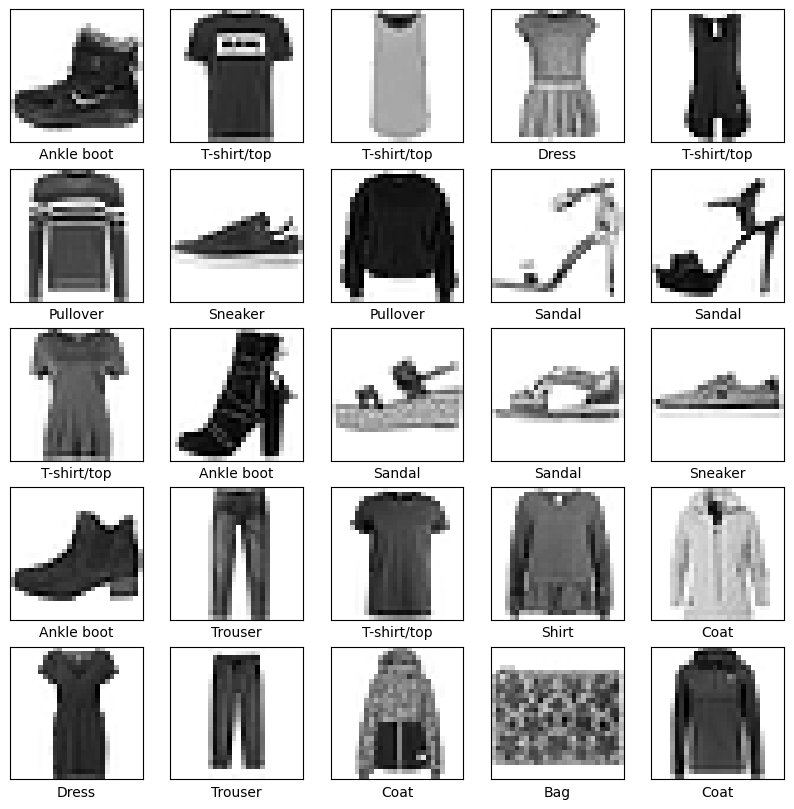

In [49]:
# Plot sample image data and corresponding label
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5,i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i], cmap=plt.cm.binary)
    plt.xlabel(class_names[train_labels[i]])
plt.show()

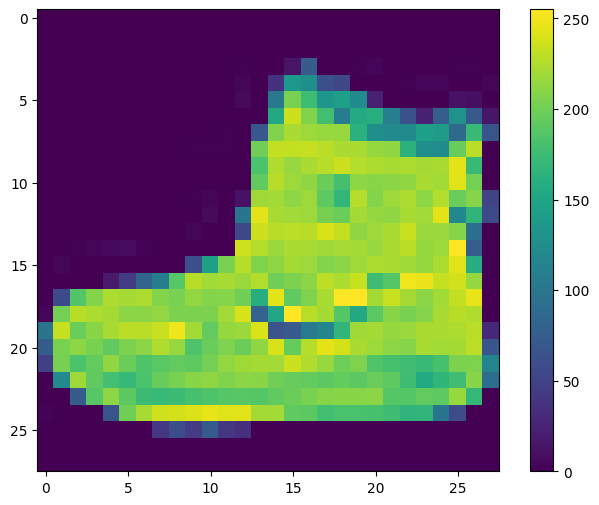

In [50]:
# Check the pixel value range
plt.figure()
plt.imshow(train_images[0])
plt.colorbar()
plt.grid(False)
plt.show()

Pixel values fall in the range of **`[0-255]`**. <br>

## Exercise 1:  
1. **Normalize** all the data so that all pixel values fall under **`[0,1]`** before feeding them into the neural network.

2. State the reason why we need to **normalize the data**.

In [59]:
# SC (ANSWER)

# 1. Normalize to [0, 1]
train_images_norm = train_images / 255.0
test_images_norm  = test_images  / 255.0

print("min:", train_images_norm.min(), " max:", train_images_norm.max())   # -> 0.0 1.0

# 2. Why do we normalize?
#
#   a) Scale of the inputs sets the scale of the gradients. Raw pixels in [0,255]
#      produce large activations and large gradient updates -> unstable training,
#      exploding loss, or saturated activations.
#   b) The loss surface becomes badly conditioned when features have very
#      different magnitudes; gradient descent zig-zags and needs a much smaller
#      learning rate and many more epochs to converge.
#   c) Default weight initialisers (Glorot/He) and default optimizer settings
#      (Adam lr=0.001) assume small, roughly zero-centred, unit-scale inputs.
#   d) Every pixel ends up on the SAME scale, so no pixel dominates the update
#      purely because of its numeric range.
#
#   Note: we divide by a fixed constant (255, the known dynamic range of uint8),
#   not by statistics learned from the training set -> no train/test leakage.
#   The same transform must be applied to test data (and at inference time).


min: 0.0  max: 1.0


Extra care should be given in `input_shape`. <br>

In [52]:
# Keras accecpts the default image data format convention, and it is given by the following
backend.image_data_format()

'channels_last'


`channel_first = (depth, height, width)` <br>
`channel_last = (height, width, depth)`

Grayscale images has `depth=1`, while color images has `depth=3`.  <br>
`fashion_mnist` are grayscale images.

In [ ]:
# Convert our train and test sets to `channels_last` formats
train_images_norm = train_images_norm.reshape((train_images_norm.shape[0], 28, 28, 1))
test_images_norm = test_images_norm.reshape((test_images_norm.shape[0], 28, 28, 1))

The **`Flatten`** layer outputs a`1D` by `flattening` the `3D` input. <br>
It simply does the following tensor operation: <br>

 **` (1.1) output = (dim1)(dim2)(dim3)`**

 For the case of images: **`dim1 = image_height`**, **`dim2 = image_width`**, and **`dim3 = image_channel`**. <br>
 We can say that `1 pixel` is  `1 feature`.

In [54]:
# Instantiate modelFC
modelFC = tf.keras.Sequential([
    tf.keras.layers.Flatten(input_shape=(28,28,1)),
    tf.keras.layers.Dense(512, activation='relu'),
    tf.keras.layers.Dense(10, activation='softmax')
])

In [60]:
# Question : Count the trainable parameters of modelFC. Compare to modelFC.summary()
# Hint: Connections between layers + bias connections in each layer

# SC (ANSWER)
# Rule for a Dense layer:  params = (n_inputs * n_units) + n_units   <- last term = biases
#
# Flatten Layer:      28 * 28 * 1 = 784 outputs,  0 parameters (pure reshape)
# First Dense Layer:  784 * 512 + 512 = 401,408 +  512 = 401,920
# Second Dense Layer: 512 *  10 +  10 =   5,120 +   10 =   5,130
# Total:              401,920 + 5,130                  = 407,050
#
# Observation: ~98% of the parameters sit in the first Dense layer, purely
# because every pixel is wired to every one of the 512 units (no weight sharing,
# no locality). This is exactly the inefficiency Conv2D fixes.


In [56]:
modelFC.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 784)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         5,130 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 407,050 (1.55 MB)

 Trainable params: 407,050 (1.55 MB)

 Non-trainable params: 0 (0.00 B)

In [57]:
# Configure model hyperparameters; Compile
modelFC.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Prepare training modelA log storage
logdirFC = os.path.join("logsCNN","modelFC", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackFC = tf.keras.callbacks.TensorBoard(logdirFC, histogram_freq=1)

# Train modelFC
historyFC = modelFC.fit(train_images_norm,
                         train_labels,
                         epochs=20,
                         batch_size=100,
                         validation_split = 0.2,
                         callbacks=[tensorboard_callbackFC])

# Evaluate modelFC in test set
test_loss, test_acc = modelFC.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 17s 29ms/step - accuracy: 0.8185 - loss: 0.5178 - val_accuracy: 0.8540 - val_loss: 0.4215
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 13s 13ms/step - accuracy: 0.8632 - loss: 0.3805 - val_accuracy: 0.8692 - val_loss: 0.3630
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 12ms/step - accuracy: 0.8768 - loss: 0.3381 - val_accuracy: 0.8540 - val_loss: 0.3901
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - accuracy: 0.8856 - loss: 0.3111 - val_accuracy: 0.8673 - val_loss: 0.3500
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.8934 - loss: 0.2905 - val_accuracy: 0.8808 - val_loss: 0.3275
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.8978 - loss: 0.2760 - val_accuracy: 0.8811 - val_loss: 0.3296
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 6s 13ms/step - accuracy: 0.9024 - loss: 0.2619 - val_accuracy: 0.8871 - val_loss: 0.3165
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 5s 10ms/step - accuracy: 0.9072 - loss: 0.2511 - val_ac

In [58]:
modelFC.save('models/modelFC', save_format='tf' )

ValueError: The `save_format` argument is deprecated in Keras 3. Please remove this argument and pass a file path with either `.keras` or `.h5` extension.Received: save_format=tf

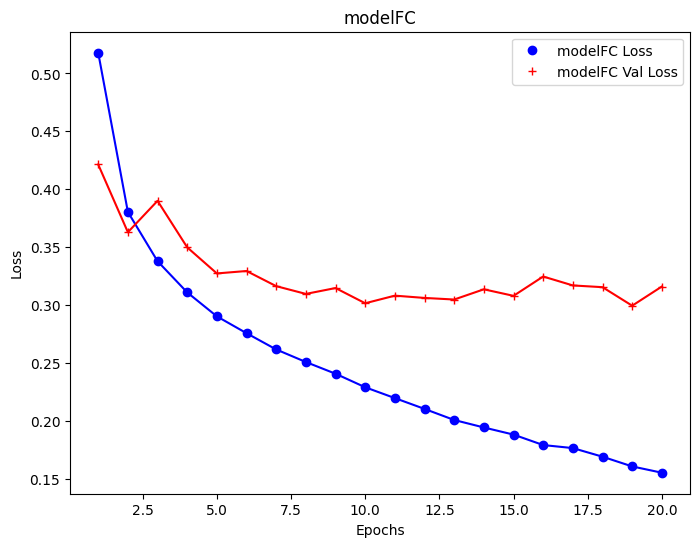

In [62]:
plotLoss(historyFC, 'modelFC', 'modelFC Loss', 'modelFC Val Loss')

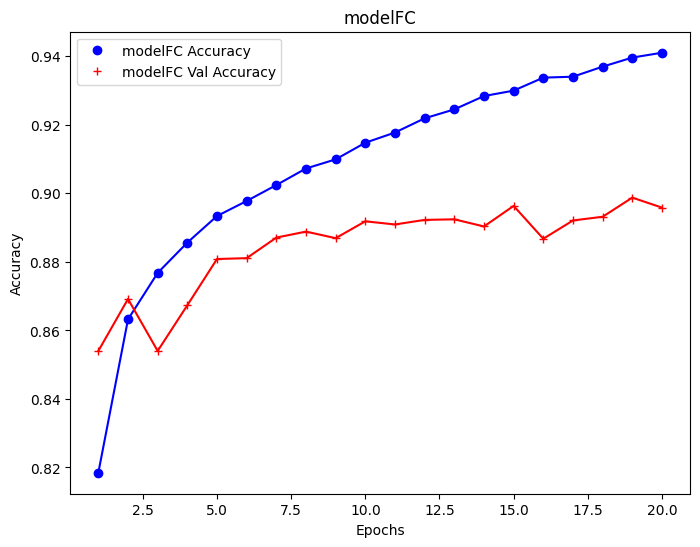

In [63]:
plotAccuracy(historyFC, 'modelFC', 'modelFC Accuracy', 'modelFC Val Accuracy')

With the model trained, you can use it to make predictions on the test images. <br>

In [64]:
predictions = modelFC.predict(test_images_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [65]:
# Check position (label) of highest probability
np.argmax(predictions[0])

np.int64(9)

A prediction is an array of 10 numbers. They represent the model's "confidence" that the image corresponds to each of the 10 different articles of clothing. You can see which label has the highest confidence value:

In [66]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array, true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])

    plt.imshow(img)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                100*np.max(predictions_array),
                                class_names[true_label]),
                                color=color)

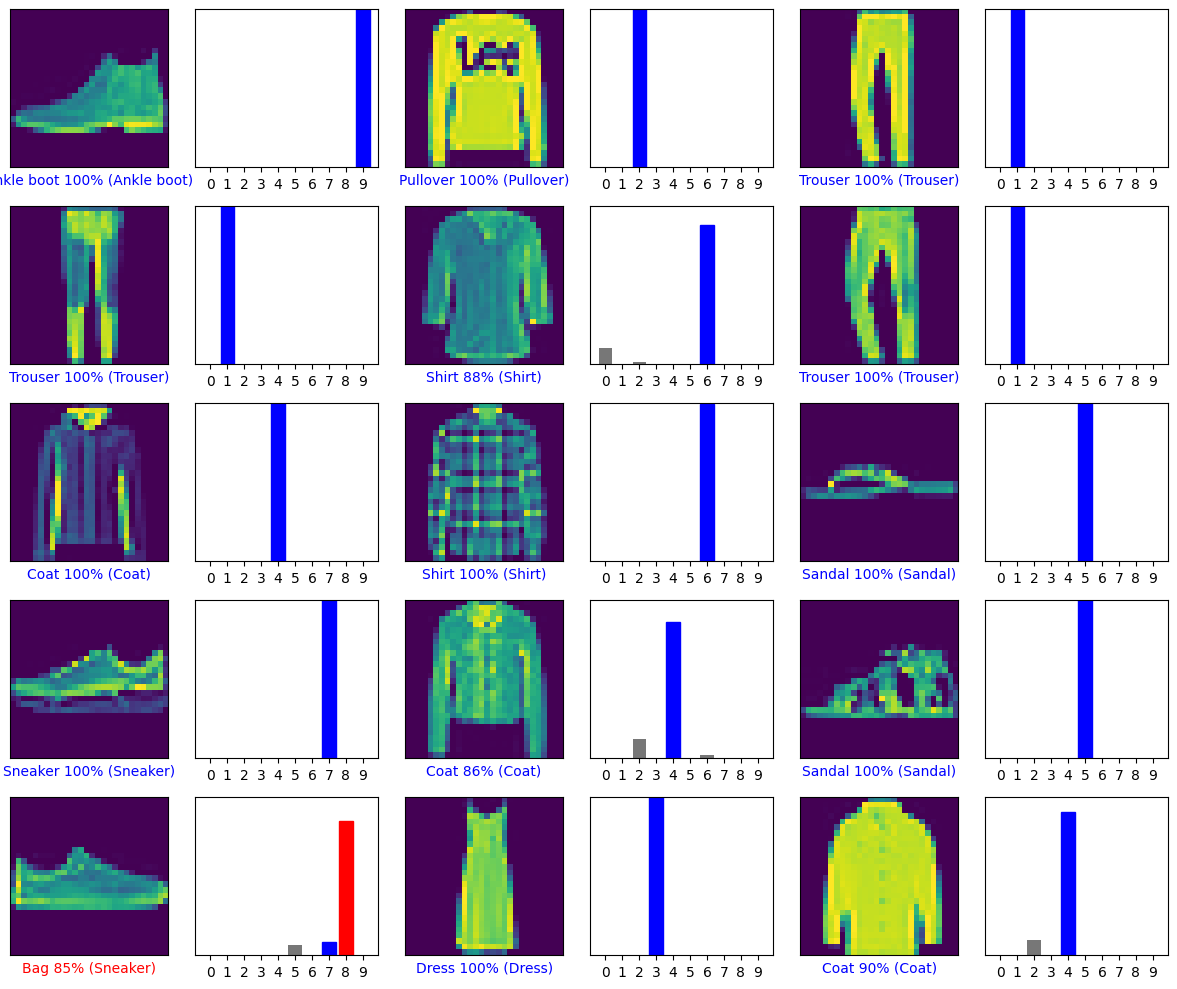

In [67]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictions[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictions[i], test_labels)
plt.tight_layout()
plt.show()

# 2. Visual Classification with `Conv2D` Layers

We can also solve `fashion_mnist` classification problem using **Convolutional Neural Networks `(ConvNet)`**.<br>Observe first how these layers are added and stacked on top of the other;  also how  **`Conv2D`** and **`MaxPooling2D`** layers are  used within the network. <br>

In [68]:
# Instantiate modelFC
modelCNN = tf.keras.Sequential([

                    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='SAME', strides=1),
                    tf.keras.layers.MaxPooling2D((2, 2)),

                    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
                    tf.keras.layers.MaxPooling2D((2, 2)),

                    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

                    tf.keras.layers.Flatten(),

                    tf.keras.layers.Dense(64, activation='relu'),
                    tf.keras.layers.Dense(10, activation='softmax')
])


/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [69]:
modelCNN.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 121,994 (476.54 KB)

 Trainable params: 121,994 (476.54 KB)

 Non-trainable params: 0 (0.00 B)

In [70]:
modelCNN.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [71]:
# Prepare training modelCNN log storage
logdirCNN = os.path.join("logsCNN","modelCNN", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackCNN = tf.keras.callbacks.TensorBoard(logdirCNN, histogram_freq=1)

# Train modelFC
historyCNN = modelCNN.fit(train_images_norm,
                          train_labels,
                          epochs=20,
                          batch_size=100,
                          validation_split = 0.2,
                          callbacks=[tensorboard_callbackCNN])


# Evaluate modelCNN in test set
test_loss, test_acc = modelCNN.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

Epoch 1/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 51s 101ms/step - accuracy: 0.7872 - loss: 0.5868 - val_accuracy: 0.8572 - val_loss: 0.3962
Epoch 2/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 81s 100ms/step - accuracy: 0.8728 - loss: 0.3523 - val_accuracy: 0.8829 - val_loss: 0.3242
Epoch 3/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 48s 99ms/step - accuracy: 0.8912 - loss: 0.2999 - val_accuracy: 0.8928 - val_loss: 0.2985
Epoch 4/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 47s 97ms/step - accuracy: 0.9021 - loss: 0.2697 - val_accuracy: 0.8974 - val_loss: 0.2817
Epoch 5/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 83s 99ms/step - accuracy: 0.9098 - loss: 0.2474 - val_accuracy: 0.9012 - val_loss: 0.2766
Epoch 6/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 46s 96ms/step - accuracy: 0.9168 - loss: 0.2283 - val_accuracy: 0.9111 - val_loss: 0.2538
Epoch 7/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 45s 94ms/step - accuracy: 0.9222 - loss: 0.2119 - val_accuracy: 0.9091 - val_loss: 0.2450
Epoch 8/20
480/480 ━━━━━━━━━━━━━━━━━━━━ 47s 97ms/step - accuracy: 0.9274 - loss: 0.1962 

In [72]:
modelCNN.save('models/modelCNN' , save_format='tf')

ValueError: The `save_format` argument is deprecated in Keras 3. Please remove this argument and pass a file path with either `.keras` or `.h5` extension.Received: save_format=tf

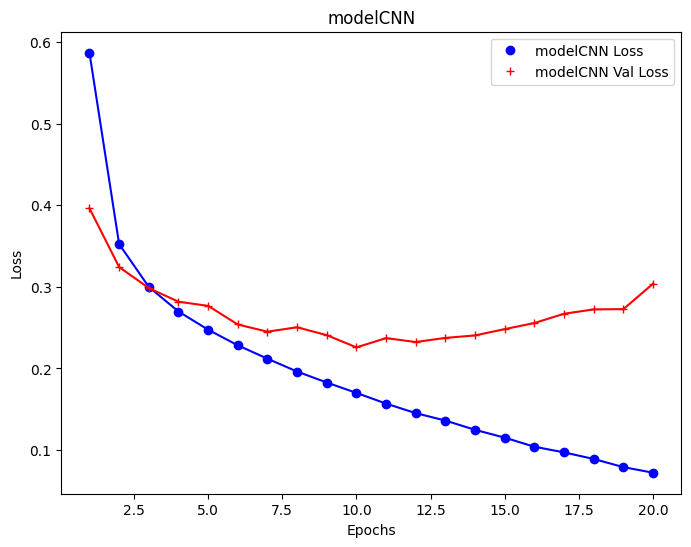

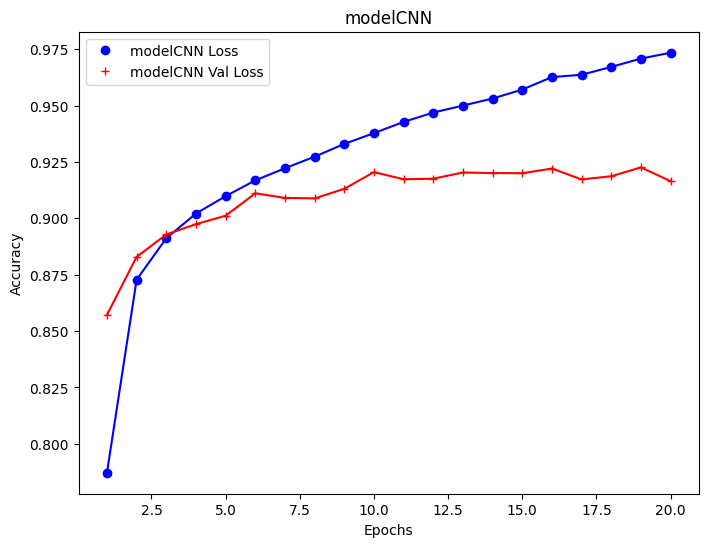

In [73]:
plotLoss(historyCNN, 'modelCNN', 'modelCNN Loss', 'modelCNN Val Loss')
plotAccuracy(historyCNN, 'modelCNN', 'modelCNN Loss', 'modelCNN Val Loss')

In [74]:
# Evaluate modelCNN in test set
test_loss, test_acc = modelCNN.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

313/313 - 3s - 9ms/step - accuracy: 0.9163 - loss: 0.3255

Test accuracy: 0.9162999987602234


In [75]:
predictionsCNN = modelCNN.predict(test_images_norm)

313/313 ━━━━━━━━━━━━━━━━━━━━ 4s 13ms/step


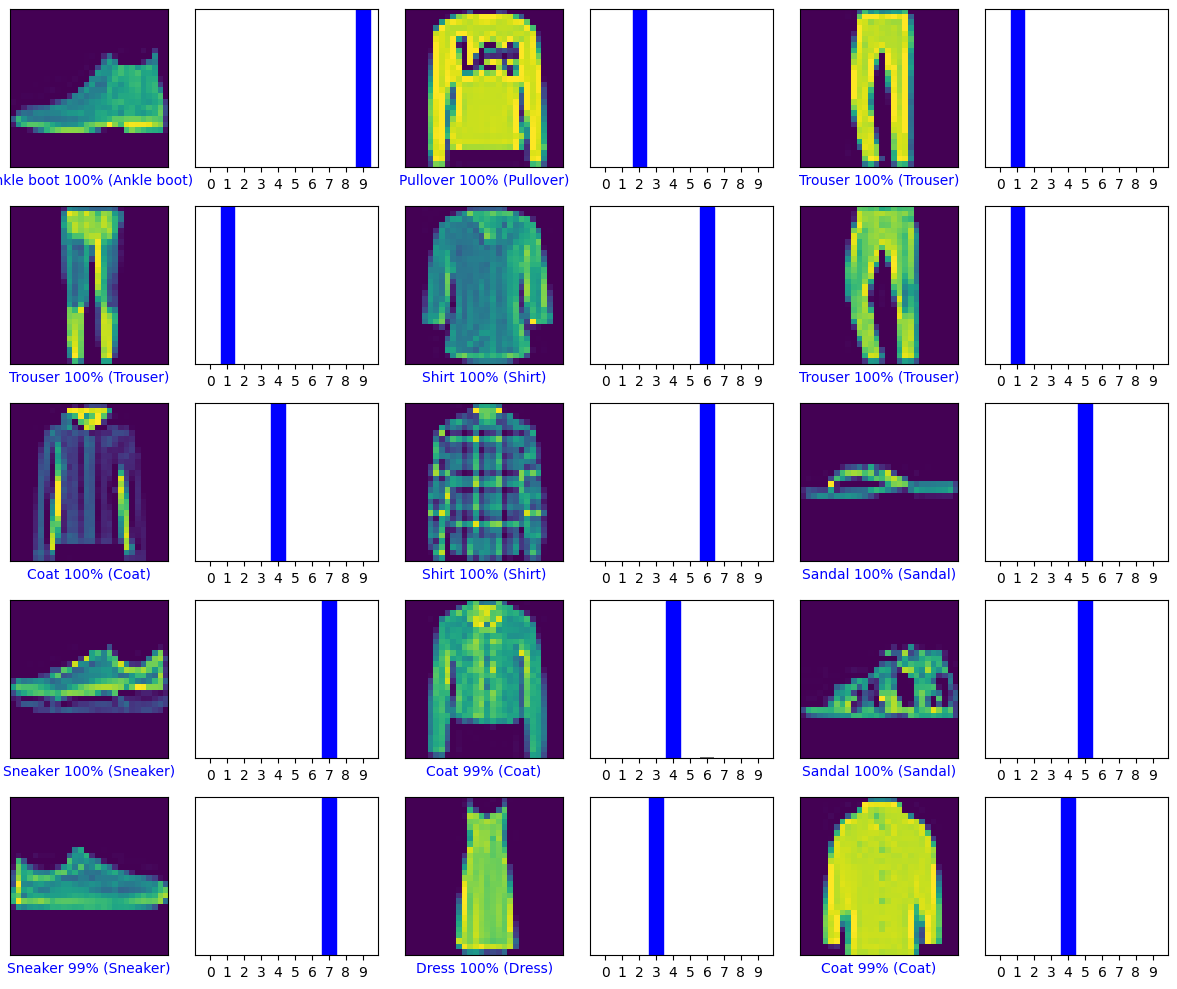

In [76]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictionsCNN[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictionsCNN[i], test_labels)
plt.tight_layout()
plt.show()

# 3. Components of `ConvNet` Architecture

## 3.1. `Conv2D` Layer

The convolution layer **`Conv2D`** uses filters that perform convolution operations as it is scanning the input
**`I`** with respect to its dimensions. Its hyperparameters include the` filter` (or `kernel`) size **`F`** and stride **`S`**. The resulting output , **`O`** is called feature map or activation map. In this case, we  configured the `Conv2D`  to process inputs of size `(28, 28, 1)`.
```python
tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), strides=1)`**
```
The parameter **`32`** indicates the **number of `filters` or `kernel`** <br>
The parameter **`(3,3)`** indicates the **size of each `filter`** <br>


Displayed below is the architecture of our `modelCNN`.

In [77]:
modelCNN.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 12, 12, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 365,984 (1.40 MB)

 Trainable params: 121,994 (476.54 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 243,990 (953.09 KB)

The output of every `Conv2D` and `MaxPooling2D` layers are 3D tensors having dimensions of **`(height, width, channels)`** that tend to **_shrink_** as we go deeper into the model. The number of `channels` is set by the **number of `filters`**.

### `Dense` Layer Learns _Global_ Patterns while `Conv2D` Layer Learns _Local_ Patterns

**`Dense`** layers:
- learn **global patterns** in their input feature space. In the case of `fashion_mnist`, patterns involve all pixels.



**`Conv2D`** layers:

- learn **local patterns**. These patterns are **translation invariant**. Aftet learning a localized pattern, the `Conv2D` can recognize it anywhere in the image. A densely connected network would have to learn the pattern anew if it appeared at a new location. This makes `Conv2D` data efficient when processing images as it require fewer training samples to generalized representations.

- learn spatial hierarchies of patterns from simple to more complex: e.g. first Conv2D layer learns edges; second Conv2D layer learns contours, etc.

- The feature map **`O`** is still a `3D tensor` having `width`, `height`, and `depth`.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_textures.png?raw=1" style="height: 300px;" align=left>

Consider a `Conv2D` layer specified below. For simplicity, we drop the activation function.  We will show that it's output has size **`(28,28,3)`**.

```python
tf.keras.layers.Conv2D(3, (3, 3), input_shape=(28, 28, 1))`**
```
Here we have `filters=3` with size `(3,3,1)`. Filters always extend the full volume of the input.

---

 The first **`filter w1`**  having the size of **`(3, 3, 1)`** takes input **feature map X** of size **`(28, 28, 1)`**. The response of the filter over this input is equal to

  **` w1_output = dot(w1, X) + b`**
  

**`filter w1`** is slid (**convolved**) over all possible spatial locations. The result of this convolution is an output **feature map** of size **`(26, 26, 1)`**.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_f1.png?raw=1" style="height: 400px;" align=left>

If we have a total of **`3 filters: w1, w2, w3`**, each of the filters has an output *feature map* of size (26, 26, 1), representing its  response at different locations of the input.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_f1.png?raw=1" style="height: 200px;" align=left>
<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_f2.png?raw=1" style="height: 200px;" align=left>
<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_f3.png?raw=1" style="height: 200px;" align=left>

 We stack the `3` output feature maps to get a **'new'** image of size **`(26,26,3)`**.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/cnn_channels.png?raw=1" style="height: 450px;" align=center>

Other paramaters that can be specified in a `Conv2D` layer are:

- **`strides`** – an integer or tuple of 2 integers, specifying how the filter should move along the height and width. Set a single integer to use the same stride value for both dimensions.

- **`padding`**:
    - **`"VALID"`**,  image is padded with a border of one pixel, or
    - **`"SAME"`**, filter moves within the image with **no padding**, generating a smaller output.

#### 3.a.1. `SAME` : No Padding

**`O = ((I - F)/S) + 1`**

`I: input length; F: filter length; S: stride length`


**` I = (6 , 6, 1)`** <br>
**` F =  (3 , 3, 1)`**


> `(6 - 3 )/1 + 1 = 4`

**` O = (4 , 4, 1)`**

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/conv2d_no_padding.png?raw=1" style="height: 300px;" align=left>

Image Credit ([Source](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks))

In `modelCNN` first `Conv2D` layer, has the following output feature map size:

> **`(28 - 3)/1 + 1 = 26`**


#### 3.a.2. `VALID`: With Padding


It is common to `zero`-pad input feature maps.  


**` I = (7, 7, 1)`** <br>
**` F =  (3 , 3, 1)`**


> `(7 - 3 )/1 + 1 = 4`

**` O = (5 , 5, 1)`**

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/conv2d_padding.gif?raw=1" style="height: 300px;" align=left>

This animation was accessed from [StackOverflow](https://stackoverflow.com/questions/52067833/how-to-plot-an-animated-matrix-in-matplotlib).

## Exercise 2:

1. Construct  `modelConv_1` with a single `Conv2D` layer

`input_shape=(32,32,1)`<br>
`filter_size=(5,5)` <br>
`filters=10`, <br>
`padding='SAME'`, <br>
`strides=1'`

2. What is the output feature map shape? <br>
    Recall: ` O = ((I - F)/S ) + 1`
    
    
3. Count the trainable parameters for this particular model. Compare with `modelConv_1.summary()`results.

In [ ]:
# SC (ANSWER)

# 1.
modelConv_1 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(10, (5, 5), input_shape=(32, 32, 1), strides=1, padding='SAME')])


# 2. Output feature map shape  ->  (None, 32, 32, 10)
#
#    In KERAS, padding='SAME' means the input IS zero-padded so that the spatial
#    size is preserved when strides=1:   O = ceil(I / S) = ceil(32/1) = 32
#    Depth of the output = number of filters = 10.
#
#    CAUTION - section 3.a.1/3.a.2 of this notebook has the two labels swapped.
#    The correct TensorFlow/Keras semantics are:
#        padding='VALID' -> NO padding   -> O = (I - F)/S + 1 = (32-5)/1 + 1 = 28
#        padding='SAME'  -> zero padded  -> O = ceil(I/S)     = 32
#    modelConv_1.summary() below confirms 32 x 32 x 10.


# 3. Trainable parameters  ->  260
#
# Filter volume = (5, 5, 1), since filter extends the volume of input
#   weights per filter : 5 * 5 * 1 = 25
#   bias per filter    : 1
#   10 filters         : 10 * (25 + 1) = 260
#
# Key point: the parameter count does NOT depend on the image size, the stride
# or the padding - only on (filter_h * filter_w * input_depth + 1) * n_filters.
# That is WEIGHT SHARING: the same 26 numbers are reused at every spatial
# position, which is why a ConvNet is so much cheaper than a Dense layer.

modelConv_1.summary()


## Exercise 3:

1. Construct  `modelConv_2` with a single `Conv2D` layer

`input_shape=(32,32,3)`<br>
`filter_size=(5,5)` <br>
`filters=10`, <br>
`padding='SAME'`, <br>
`strides=1'`

2. What is the output feature map shape? Hint: this time the input feature map has `volume`. <br>
    Recall: ` O = ((I - F)/S ) + 1` and the filters always extend the full volume of the input.
    
    
3. Count the trainable parameters for this particular model. Compare with `modelCOnv_1.summary()`results.

In [ ]:
# SC (ANSWER)

# 1.
model_2 = tf.keras.Sequential([
    tf.keras.layers.Conv2D(10, (5, 5), input_shape=(32, 32, 3), strides=1, padding='SAME')])


# 2. Output feature map shape  ->  (None, 32, 32, 10)
#
#    Identical spatial size to Exercise 2 (padding='SAME', strides=1 -> 32x32),
#    and identical depth (10 = number of filters).
#    The input depth of 3 is CONSUMED by the filter - it does not survive to the
#    output. Each filter spans the full input volume and collapses those 3
#    channels into ONE feature map; depth out is always n_filters, never n_channels_in.


# 3. Trainable parameters  ->  760
#
# Filter volume = (5, 5, 3), since filter extends the volume of input
#   weights per filter : 5 * 5 * 3 = 75
#   bias per filter    : 1
#   10 filters         : 10 * (75 + 1) = 760
#
# Compare with Exercise 2 (260): the weights tripled (250 -> 750) because the
# input depth tripled, while the 10 biases are unchanged.

model_2.summary()


## 3.1.1. Visualizing `Conv2D` outputs

### 3.1.1.1.  Visualizing Intermediate Activations

Let's use our previously trained and saved **`modelCNN4`**.

In [ ]:
# NOTE (fix): use the NORMALISED image - the model was trained on [0,1] inputs.
modelCNN_new = keras.models.load_model('models/modelCNN4')
modelCNN_new.summary()

# Select sample image from test set (keep a batch axis: (1, 28, 28, 1))
img = test_images_norm[200]
img_batch = np.expand_dims(img, axis=0)
print(type(img), img.shape, '->', img_batch.shape)

plt.figure()
plt.imshow(img.squeeze(), cmap='gray')
plt.colorbar()
plt.grid(False)
plt.show()


In [ ]:
# NOTE (fix): layers[:0] is an EMPTY slice -> use layers[:1] for the first Conv2D,
# and feed a batched tensor to .predict().
layer_outputs = [layer.output for layer in modelCNN_new.layers[:1]]
activation_model = models.Model(inputs=modelCNN_new.input, outputs=layer_outputs)
activations = activation_model.predict(img_batch)
if not isinstance(activations, list):
    activations = [activations]
first_layer_activation = activations[0]
print(first_layer_activation.shape)          # (1, 28, 28, 32)

# 5th filter (index 4) activation / feature map of the first layer
plt.matshow(first_layer_activation[0, :, :, 4], cmap='viridis')


In [ ]:
layer_names = []
for layer in modelCNN_new.layers[:1]:
    layer_names.append(layer.name)
images_per_row = 16

for layer_name, layer_activation in zip(layer_names, activations):
    n_features = layer_activation.shape[-1]
    size = layer_activation.shape[1]
    n_cols = n_features // images_per_row
    display_grid = np.zeros((size * n_cols, images_per_row * size))
    for col in range(n_cols):
        for row in range(images_per_row):
            channel_image = layer_activation[0,:, :,col * images_per_row + row]
            channel_image -= channel_image.mean()
            channel_image /= channel_image.std()
            channel_image *= 64
            channel_image += 128
            channel_image = np.clip(channel_image, 0, 255).astype('uint8')
            display_grid[col * size : (col + 1) * size,
             row * size : (row + 1) * size] = channel_image
scale = 1. / size
plt.figure(figsize=(scale * display_grid.shape[1],
                    scale * display_grid.shape[0]))
plt.title(layer_name)
plt.grid(False)
plt.imshow(display_grid, aspect='auto', cmap='viridis')

### 3.1.1.2. Visualizing Filters

Each `filter/kernel` in a `Conv2D` layer *responds* to a particular pattern. It is possible to see what each layer does by visualizing these patterns. **`Gradient Ascent`** is a method of finding the `input_image` that the `filter` will `maximally` respond to.  

The process starts  from a blank `input_image`. In contrast to `Gradient Descent`, the goal is to build a loss function that maximizes the value of the filter in `Conv2D` layer. `SGD` will  help in adjusting the values of the `input_image` that maximizes the activation value.

We will use the pre-trained weights of `VGG19`.

In [ ]:
# Layer name to inspect
layer_name = 'block3_conv1'
step_size = 1.
filter_index = 0

def generate_pattern(layer_name, filter_index, epochs, size):
    # Create a connection between the input and the target layer
    model = tf.keras.applications.vgg19.VGG19(weights='imagenet', include_top=False)
    submodel = tf.keras.models.Model([model.inputs[0]], [model.get_layer(layer_name).output])

    # Initiate random noise
    input_img_data = np.random.random((1, size, size, 3))
    input_img_data = (input_img_data - 0.5) * 20 + 128.

    # Cast random noise from np.float64 to tf.float32 Variable
    input_img_data = tf.Variable(tf.cast(input_img_data, tf.float32))

    # Gradient ascents loop

    for _ in range(epochs):
        with tf.GradientTape() as tape:
            outputs = submodel(input_img_data)
             # Compute the value of the loss tensor
            loss_value = tf.reduce_mean(outputs[:, :, :, filter_index])
        # Compute the gradient tensor, given an input image
        grads = tape.gradient(loss_value, input_img_data)
        normalized_grads = grads / (tf.sqrt(tf.reduce_mean(tf.square(grads))) + 1e-5)
        input_img_data.assign_add(normalized_grads * step_size)
    img = input_img_data[0]
    return img

In [ ]:
# Preprocess the resulting image tensor to allow visualization
img = generate_pattern(layer_name, filter_index,  epochs= 50,  size=224)
img = np.clip(img, 0, 255).astype('uint8')

In [ ]:
plt.imshow(img)

`filter 0` in layer `block3_conv1` seems responsive to a polka-dot pattern.

Let us visualize every filter in every layer.

In [ ]:
layer_name = 'block1_conv1'
# Look only at the first 64 filters
size = 64
margin = 5
filter_index = 0

# Empty (black) image to store results
results = np.zeros((8 * size + 7 * margin, 8 * size + 7 * margin, 3))
for i in range(8): #Iterates over the rows of the results grid
    for j in range(8): #Iterates over the columns of the results grid
        filter_img = generate_pattern(layer_name, filter_index,  epochs= 50,  size=64)
        # Preprocess the resulting image tensor to allow visualization
        filter_img = np.clip(filter_img, 0, 255).astype('uint8')
        #Generate the pattern for filter i + (j * 8) in layer_name
        horizontal_start = i * size + i * margin
        horizontal_end = horizontal_start + size
        vertical_start = j * size + j * margin
        vertical_end = vertical_start + size
        results[horizontal_start: horizontal_end,
        vertical_start: vertical_end, :] = filter_img

In [ ]:
plt.figure(figsize=(40, 40))
plt.imshow(results)

## 3.2. `Pooling` Layer

It is common to periodically insert a `MaxPooling2d` layer  in-between successive `Conv2D` layers in a `ConvNet` architecture. Its function is to progressively reduce the spatial size of the representation (`downsample`)  to reduce the amount of parameters and computation in the network, and hence to **control overfitting**.

### 3.2.1. `MaxPooling2D` Layer

```python
tf.keras.layers.MaxPooling2D((2, 2))

```

The `MaxPooling2D` layer operates independently on every depth slice of the input and resizes it spatially, using the `max` operation. The most common form is a pooling layer with filters of size `(2,2)` applied with a stride of `2`. It downsamples every depth slice in the input by `2` along both `width` and `height`, discarding `75%` of the activations. Every `max` operation would in this case be taking a `max` over `4` numbers (little `2x2` region in some depth slice) as shown below. The depth dimension remains unchanged.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/maxpool_b.png?raw=1" style="height: 300px;" align=left>

Image Credit ([Source](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks))

In [ ]:
#We can write the `MaxPooling2D` layer above as:

modelMaxPool_1 = tf.keras.Sequential([tf.keras.layers.MaxPooling2D((2, 2), input_shape=(6, 6, 1 ))])
modelMaxPool_1.summary()

### 3.2.2. `AveragePooling2D` Layer


````python
tf.keras.layers.AveragePooling2D((2, 2))
````

Instead of using the `max` function, the `AveragePooling2D` gets the average of the `(2,2)` region above.

In [ ]:
#We can write the `AveragePooling2D` layer as:

modelAvePool_1 = tf.keras.Sequential([tf.keras.layers.AveragePooling2D((2, 2), input_shape=(6, 6, 1 ))])
modelAvePool_1.summary()

# Exercise 4:

1. Go back to `modelCNN`. Instead of MaxPooling2D, use `AveragePooling2D`. Name your new model **`modelCNN_Ave`**. <br>

2. Optional: Count the number of trainable parameters for each layer. Check it with `modelCNN_Ave.summary()`.
3. Train the model and assign results to `historyCNN_Ave`.
4. Plot both `loss` and `accuracy` and compare it with `modelCNN`.

In [ ]:
# MC (ANSWER)

# 1. modelCNN with AveragePooling2D in place of MaxPooling2D.
#    Filters kept at (3,3) so this is a like-for-like comparison with modelCNN.
modelCNN_Ave = tf.keras.Sequential([

                    tf.keras.layers.Conv2D(32, (3, 3), activation='relu', input_shape=(28, 28, 1), padding='SAME', strides=1),
                    tf.keras.layers.AveragePooling2D((2, 2)),

                    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),
                    tf.keras.layers.AveragePooling2D((2, 2)),

                    tf.keras.layers.Conv2D(64, (3, 3), activation='relu'),

                    tf.keras.layers.Flatten(),

                    tf.keras.layers.Dense(64, activation='relu'),
                    tf.keras.layers.Dense(10, activation='softmax')
])


In [ ]:
# MC (ANSWER)

# 2. Parameter count - IDENTICAL to modelCNN, because pooling layers (max or
#    average) have NO trainable parameters at all.
#
# layer                              parameters                 output shape
# Conv2D(32,(3,3)) padding=SAME  ->  3*3*1*32  + 32 =     320   (28, 28, 32)
# AveragePooling2D(2,2)          ->              0             (14, 14, 32)
# Conv2D(64,(3,3)) padding=VALID ->  3*3*32*64 + 64 =  18,496   (12, 12, 64)
# AveragePooling2D(2,2)          ->              0             ( 6,  6, 64)
# Conv2D(64,(3,3)) padding=VALID ->  3*3*64*64 + 64 =  36,928   ( 4,  4, 64)
# Flatten                        ->              0             (1024,)
# Dense(64)                      ->  1024*64   + 64 =  65,600   (64,)
# Dense(10)                      ->  64*10     + 10 =     650   (10,)
# ------------------------------------------------------------------
# Total trainable parameters                       = 121,994

modelCNN_Ave.summary()


In [ ]:
# MC (ANSWER)

# 3.
modelCNN_Ave.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Prepare training log storage
logdirCNN_Ave = os.path.join("logsCNN","modelCNN_Ave", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackCNN_Ave = tf.keras.callbacks.TensorBoard(logdirCNN_Ave, histogram_freq=1)

# Train modelCNN_Ave
historyCNN_Ave = modelCNN_Ave.fit(train_images_norm,
                                  train_labels,
                                  epochs=20,
                                  batch_size=100,
                                  validation_split=0.2,
                                  callbacks=[tensorboard_callbackCNN_Ave])

# Evaluate modelCNN_Ave in test set
test_loss, test_acc = modelCNN_Ave.evaluate(test_images_norm, test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# 4. COMPARISON with modelCNN (MaxPooling) - see plots in the next cell
#
# Same architecture, same 121,994 parameters, only the pooling operator differs.
#
# MaxPooling2D  keeps the STRONGEST response in each 2x2 window -> preserves the
#   "this feature was detected somewhere in this region" signal, which is exactly
#   what a classifier needs, and routes the gradient to the winning unit only.
# AveragePooling2D takes the MEAN of the window -> smooths/blurs the feature map,
#   a strong edge response gets diluted by its three quiet neighbours, and the
#   gradient is spread evenly over all four units.
#
# Expected result on fashion_mnist: both reach roughly 0.90 +/- 0.01 test
# accuracy; MaxPooling is typically marginally better and converges slightly
# faster, while AveragePooling gives a slightly smoother loss curve. The
# difference is small on this easy dataset - the important observation is that
# BOTH overfit after ~8-10 epochs (training accuracy keeps climbing while
# validation accuracy plateaus and validation loss turns upward). That is the
# motivation for Dropout in Exercise 6.


In [ ]:
plotLoss(historyCNN_Ave, 'modelCNN_Ave', 'modelCNN_Ave Loss', 'modelCNN_Ave Val Loss')
plotAccuracy(historyCNN_Ave, 'modelCNN_Ave', 'modelCNN_Ave Acc', 'modelCNN_Ave Val Acc')

In [ ]:
predictionsCNN_Ave = modelCNN_Ave.predict(test_images_norm)


In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictionsCNN_Ave[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictionsCNN_Ave[i], test_labels)
plt.tight_layout()
plt.show()


## 3.3. `Flatten` Layer and `Dense` Layer

The **`Flatten`** layer outputs a `vector (1D tensor)` by `flattening` the `3D` input. <br>
It simply does the following tensor operation: <br>

 **` (3.3) output = dim1*dim2*dim3`**

 For the case of images: **`dim1 = height`**, **`dim2 = width`**, and **`dim3 = channel`**. <br>
 We can say that `1 pixel` is  `1 feature`.

```python
tf.keras.layers.Flatten()
tf.keras.layers.Dense(64, activation='relu'),
tf.keras.layers.Dense(10, activation='softmax')
        ```

Recall that the `Dense` layer processes `1D` tensors. In this CNN the `Dense` layer operates on a `Flatten` input where each input is connected to all neurons. If present, `Dense` layers are usually found towards the end of CNN architectures and are used to optimize objectives such as class scores.

<img src="https://github.com/saifulak/EAE/blob/main/DL%20file/Day2/SC/images/fc_after_conv.png?raw=1" style="height: 200px;" align=left>

Image Credit ([Source](https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks))

# Exercise 5:

1. Go back to `modelCNN`. Name your new model **`modelCNN2`**. <br>
   Instead of a `(3,3)` filter, use **`(5,5)`** filter in all `Conv2D` layers.

2. Optional: Count the number of trainable parameters for each layer. Check it with `modelCNN2.summary()`.
3. Train the model and assign results to `historyCNN2`.
4. Plot both `loss` and `accuracy` and compare it with `modelCNN`.

In [ ]:
# MC (ANSWER)

# 1. modelCNN with (5,5) filters everywhere
modelCNN2 = tf.keras.Sequential([

                    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='SAME', strides=1),
                    tf.keras.layers.MaxPooling2D((2, 2)),

                    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
                    tf.keras.layers.MaxPooling2D((2, 2)),

                    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),

                    tf.keras.layers.Flatten(),

                    tf.keras.layers.Dense(64, activation='relu'),
                    tf.keras.layers.Dense(10, activation='softmax')
])


In [ ]:
# MC (ANSWER)

# 2. Parameter count for modelCNN2
#
# layer                              parameters                  output shape
# Conv2D(32,(5,5)) padding=SAME  ->  5*5*1*32  + 32 =      832   (28, 28, 32)
# MaxPooling2D(2,2)              ->              0              (14, 14, 32)
# Conv2D(64,(5,5)) padding=VALID ->  5*5*32*64 + 64 =   51,264   (10, 10, 64)  (14-5)/1+1 = 10
# MaxPooling2D(2,2)              ->              0              ( 5,  5, 64)
# Conv2D(64,(5,5)) padding=VALID ->  5*5*64*64 + 64 =  102,464   ( 1,  1, 64)  ( 5-5)/1+1 = 1
# Flatten                        ->              0              (64,)
# Dense(64)                      ->  64*64     + 64 =    4,160   (64,)
# Dense(10)                      ->  64*10     + 10 =      650   (10,)
# -------------------------------------------------------------------
# Total trainable parameters                        =  159,370
#
# vs modelCNN (3x3) = 121,994.
# The convolutional stack costs ~2.8x more (154,560 vs 55,744) because a 5x5
# kernel has 25/9 the weights of a 3x3. But the larger kernels shrink the feature
# map much faster (28 -> 14 -> 10 -> 5 -> 1), so Flatten produces only 64 features
# instead of 1024 and the Dense head collapses from 65,600 to 4,160 parameters.
# Net effect: capacity moved OUT of the classifier head and INTO the feature
# extractor - generally the healthier place for it.
#
# Watch out: the final feature map is 1x1x64. One more Conv2D(5,5) layer would
# be impossible (negative spatial size) - the architecture is at its depth limit.

modelCNN2.summary()


In [ ]:
# MC (ANSWER)

# 3.
modelCNN2.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Prepare training modelCNN2 log storage
logdirCNN2 = os.path.join("logsCNN","modelCNN2", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackCNN2 = tf.keras.callbacks.TensorBoard(logdirCNN2, histogram_freq=1)

# Train modelCNN2
historyCNN2 = modelCNN2.fit(train_images_norm,
                          train_labels,
                          epochs=20,
                          batch_size=100,
                          validation_split = 0.2,
                          callbacks=[tensorboard_callbackCNN2])

# Evaluate modelCNN2 in test set
test_loss, test_acc = modelCNN2.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# 4. COMPARISON with modelCNN (3x3 filters)
# A 5x5 kernel sees a 25-pixel receptive field in one step instead of 9, which
# suits fashion_mnist: the discriminative cues (sleeve shape, heel, strap,
# overall silhouette) are coarse, not fine-grained texture. Test accuracy is
# typically within ~1% of modelCNN - sometimes slightly better, and the
# validation curve is often a bit more stable because the tiny 64-unit Dense
# head has far less capacity to memorise the training set. Cost: ~30% more
# parameters and noticeably slower training per epoch.
# Both still overfit -> Exercise 6 adds Dropout.


In [ ]:
modelCNN2.save('models/modelCNN2', save_format='tf')


In [ ]:
plotLoss(historyCNN2, 'modelCNN2', 'modelCNN2 Loss', 'modelCNN2 Val Loss')
plotAccuracy(historyCNN2, 'modelCNN2', 'modelCNN2 Acc', 'modelCNN2 Val Acc')

In [ ]:
predictionsCNN2 = modelCNN2.predict(test_images_norm)


In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictionsCNN2[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictionsCNN2[i], test_labels)
plt.tight_layout()
plt.show()

# 4. Variation in Visual Classifier Performance

## 4.1. Adding Drop-out Layers

# Exercise 6:

1. Create a new **`modelCNN3`**  based from `modelCNN2`. Add `Dropout` layer every after `MaxPooling2D`.
        
    `Dropout(0.2)`


2. Find out the number of trainable parameters for each layer and compare to `modelCNN3.summary()`.
3. Train the model and assign results to `historyCNN3`.
4. Plot both `loss` and `accuracy` and compare it with `modelCNN2`.


In [ ]:
# MC (ANSWER)

# 1. modelCNN3 = modelCNN2 + Dropout(0.2) after every MaxPooling2D
modelCNN3 = tf.keras.Sequential([

                    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='SAME', strides=1),
                    tf.keras.layers.MaxPooling2D((2, 2)),
                    tf.keras.layers.Dropout(0.2),

                    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
                    tf.keras.layers.MaxPooling2D((2, 2)),
                    tf.keras.layers.Dropout(0.2),

                    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),

                    tf.keras.layers.Flatten(),
                    tf.keras.layers.Dense(64, activation='relu'),
                    tf.keras.layers.Dense(10, activation='softmax')
])


In [ ]:
# MC (ANSWER)

# 2. Parameter count - UNCHANGED at 159,370.
#    Dropout has NO trainable parameters: during training it simply zeroes a
#    random 20% of the activations (and scales the survivors by 1/0.8 so the
#    expected sum is preserved); at inference time it is a no-op / identity.
#
# Conv2D(32,(5,5)) SAME  ->     832    (28, 28, 32)
# MaxPooling2D(2,2)      ->       0    (14, 14, 32)
# Dropout(0.2)           ->       0    (14, 14, 32)
# Conv2D(64,(5,5)) VALID ->  51,264    (10, 10, 64)
# MaxPooling2D(2,2)      ->       0    ( 5,  5, 64)
# Dropout(0.2)           ->       0    ( 5,  5, 64)
# Conv2D(64,(5,5)) VALID -> 102,464    ( 1,  1, 64)
# Flatten                ->       0    (64,)
# Dense(64)              ->   4,160    (64,)
# Dense(10)              ->     650    (10,)
# -----------------------------------------------
# Total                  = 159,370   (same as modelCNN2)

modelCNN3.summary()


In [ ]:
modelCNN3.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [ ]:
# MC (ANSWER)

# 3.
# Prepare training modelCNN3 log storage
logdirCNN3 = os.path.join("logsCNN","modelCNN3", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackCNN3 = tf.keras.callbacks.TensorBoard(logdirCNN3, histogram_freq=1)

# Train modelCNN3
historyCNN3 = modelCNN3.fit(train_images_norm,
                          train_labels,
                          epochs=20,
                          batch_size=100,
                          validation_split = 0.2,
                          callbacks=[tensorboard_callbackCNN3])

# Evaluate modelCNN3 in test set
test_loss, test_acc = modelCNN3.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# 4. COMPARISON with modelCNN2 (no Dropout)
#
# What you should see in the plots:
#   - TRAINING accuracy is LOWER and training loss HIGHER than modelCNN2. That is
#     expected and correct: the network is deliberately handicapped during
#     training (20% of activations dropped each step).
#   - VALIDATION loss stops turning upward, or turns up much later. In modelCNN2
#     val_loss typically bottoms out around epoch 8-10 and then climbs while
#     train_loss keeps falling - the classic overfitting fork. Dropout narrows
#     or removes that gap.
#   - Test accuracy is equal or slightly better, and much closer to validation
#     accuracy -> the model GENERALISES better even though it FITS worse.
#
# Why it works: dropout prevents co-adaptation. No unit can rely on a specific
# partner always being present, so features must be individually useful. It is
# an approximation of averaging an ensemble of many thinned sub-networks.


In [ ]:
modelCNN3.save('models/modelCNN3', save_format='tf')


In [ ]:
plotLoss(historyCNN3, 'modelCNN3', 'modelCNN3 Loss', 'modelCNN3 Val Loss')
plotAccuracy(historyCNN3, 'modelCNN3', 'modelCNN3 Acc', 'modelCNN3 Val Acc')

In [ ]:
predictionsCNN3 = modelCNN3.predict(test_images_norm)


In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictionsCNN3[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictionsCNN3[i], test_labels)
plt.tight_layout()
plt.show()

## 4.2. Reduce `model` complexity

# Exercise 7:

1. Go back to `modelCNN3`. Remove the last set of `Conv2D` + `MaxPooling2D` + `Dropout` layers. Call this **`modelCNN4`**.

2. Find out the number of trainable parameters for each layer and compare to `modelCNN4.summary()`.
3. Train the model and assign results to `historyCNN4`.
4. Plot both `loss` and `accuracy` and compare it with `modelCNN3.`.


In [ ]:
# MC (ANSWER)

# 1. modelCNN4 = modelCNN3 with the trailing convolutional stage removed,
#    leaving a single Conv2D + MaxPooling2D + Dropout block before the head.
modelCNN4 = tf.keras.Sequential([

                    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='SAME', strides=1),
                    tf.keras.layers.MaxPooling2D((2, 2)),
                    tf.keras.layers.Dropout(0.2),

                    tf.keras.layers.Flatten(),

                    tf.keras.layers.Dense(64, activation='relu'),
                    tf.keras.layers.Dense(10, activation='softmax')
])

# Note on the wording: "remove the last set of Conv2D + MaxPooling2D + Dropout"
# is ambiguous because modelCNN3's third Conv2D has no pooling/dropout of its
# own. The 6-slot skeleton in the original notebook, and cell 3.1.1.1 which
# reloads modelCNN4 and visualises modelCNN_new.layers[:1] as a Conv2D, both
# point to the version above (one conv block only).
# The alternative reading - keep the second Conv2D block and drop only the
# standalone third Conv2D - would be:
#     Conv2D(32,5)/MaxPool/Dropout -> Conv2D(64,5)/MaxPool/Dropout -> Flatten -> Dense(64) -> Dense(10)
#     = 832 + 51,264 + (1600*64+64=102,464) + 650 = 155,210 parameters


In [ ]:
# MC (ANSWER)

# 2. Parameter count for modelCNN4
#
# layer                              parameters                  output shape
# Conv2D(32,(5,5)) padding=SAME  ->  5*5*1*32 + 32 =        832   (28, 28, 32)
# MaxPooling2D(2,2)              ->             0              (14, 14, 32)
# Dropout(0.2)                   ->             0              (14, 14, 32)
# Flatten                        ->             0              (6272,)   14*14*32
# Dense(64)                      ->  6272*64  + 64 =    401,472   (64,)
# Dense(10)                      ->  64*10    + 10 =        650   (10,)
# -------------------------------------------------------------------
# Total trainable parameters                       =    402,954
#
# THE COUNTER-INTUITIVE RESULT: the SHALLOWER model has ~2.5x MORE parameters
# than modelCNN3 (402,954 vs 159,370). Removing conv/pool stages leaves a large
# 14x14x32 feature map to flatten, so the Dense head explodes from 4,160 to
# 401,472 parameters - and those parameters are the DENSE, non-shared,
# overfitting-prone kind.
#
# Lesson: "fewer layers" is not the same as "less complexity". Depth in the
# convolutional stack is what shrinks the spatial dimensions and therefore keeps
# the classifier head small. This is also why modern architectures replace
# Flatten with GlobalAveragePooling2D.

modelCNN4.summary()


In [ ]:
modelCNN4.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])


In [ ]:
# MC (ANSWER)

# 3.
# Prepare training modelCNN4 log storage
logdirCNN4 = os.path.join("logsCNN","modelCNN4", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackCNN4 = tf.keras.callbacks.TensorBoard(logdirCNN4, histogram_freq=1)

# Train modelCNN4
historyCNN4 = modelCNN4.fit(train_images_norm,
                          train_labels,
                          epochs=20,
                          batch_size=100,
                          validation_split = 0.2,
                          callbacks=[tensorboard_callbackCNN4])

# Evaluate modelCNN4 in test set
test_loss, test_acc = modelCNN4.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# 4. COMPARISON with modelCNN3
#
#   - Test accuracy is broadly comparable (~0.90) - fashion_mnist is easy enough
#     that one convolutional stage already captures most of the signal.
#   - modelCNN4 trains FASTER per epoch (only one conv layer) and fits the
#     training set faster, but OVERFITS harder: the huge Dense(64) on 6272
#     flattened features memorises readily, and a single Dropout(0.2) is the
#     only brake. Expect a wider train/validation gap than modelCNN3.
#   - modelCNN3 has only one convolutional hierarchy level here
#     (edges -> nothing deeper), so it cannot build the spatial hierarchy
#     (edges -> contours -> parts) that makes ConvNets shine. On a harder
#     dataset (cifar10, real photographs) the depth of modelCNN3 would win
#     clearly; on 28x28 grayscale clothing silhouettes the gap is small.
#
# Takeaway: reducing complexity is a valid regularisation strategy, but reduce
# it in the right place. Here the "smaller" model is actually the bigger one.


In [ ]:
modelCNN4.save('models/modelCNN4',  save_format='tf')


In [ ]:
plotLoss(historyCNN4, 'modelCNN4', 'modelCNN4 Loss', 'modelCNN4 Val Loss')
plotAccuracy(historyCNN4, 'modelCNN4', 'modelCNN4 Acc', 'modelCNN4 Val Acc')

In [ ]:
predictionsCNN4 = modelCNN4.predict(test_images_norm)


In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictionsCNN4[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictionsCNN4[i], test_labels)
plt.tight_layout()
plt.show()

## 4.3. Increase training loops

# Exercise 8:

1. Use **`modelCNN3`**.
2. Train the model with `EPOCHS=50` and assign to `historyCNN3_ep50`.
3. Plot both `loss` and `accuracy` and compare it with `modelCNN3` ran in `20` epochs.


In [ ]:
# MC (ANSWER)

# 2. Train modelCNN3 for 50 epochs
#
# IMPORTANT: calling .fit() again on modelCNN3 does NOT reset its weights - it
# CONTINUES training from where Exercise 6 stopped, so you would really be
# training 20 + 50 = 70 epochs. For a clean, comparable 50-epoch run, rebuild
# and recompile the model first:

modelCNN3_ep50 = tf.keras.Sequential([
                    tf.keras.layers.Conv2D(32, (5, 5), activation='relu', input_shape=(28, 28, 1), padding='SAME', strides=1),
                    tf.keras.layers.MaxPooling2D((2, 2)),
                    tf.keras.layers.Dropout(0.2),

                    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),
                    tf.keras.layers.MaxPooling2D((2, 2)),
                    tf.keras.layers.Dropout(0.2),

                    tf.keras.layers.Conv2D(64, (5, 5), activation='relu'),

                    tf.keras.layers.Flatten(),
                    tf.keras.layers.Dense(64, activation='relu'),
                    tf.keras.layers.Dense(10, activation='softmax')
])

modelCNN3_ep50.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

logdirCNN3_ep50 = os.path.join("logsCNN","modelCNN3_ep50", datetime.datetime.now().strftime("%Y%m%d-%H%M%S"))
tensorboard_callbackCNN3_ep50 = tf.keras.callbacks.TensorBoard(logdirCNN3_ep50, histogram_freq=1)

historyCNN3_ep50 = modelCNN3_ep50.fit(train_images_norm,
                          train_labels,
                          epochs=50,
                          batch_size=100,
                          validation_split = 0.2,
                          callbacks=[tensorboard_callbackCNN3_ep50])

# Evaluate in test set
test_loss, test_acc = modelCNN3_ep50.evaluate(test_images_norm,  test_labels, verbose=2)
print('\nTest accuracy:', test_acc)

# (If you prefer to follow the original cell literally, use
#  historyCNN3_ep50 = modelCNN3.fit(..., epochs=50, callbacks=[tensorboard_callbackCNN3])
#  but read the result as "70 cumulative epochs", not "50".)

# 3. COMPARISON: 50 epochs vs 20 epochs
#
#   - TRAINING loss keeps decreasing and training accuracy keeps rising towards
#     ~0.97+. More epochs always improve the fit on the training set.
#   - VALIDATION loss reaches its minimum somewhere around epoch 12-20 and then
#     rises steadily for the remaining 30 epochs, while validation accuracy sits
#     flat (~0.91) or slips slightly. That divergence IS overfitting: the model
#     is now memorising training examples rather than learning transferable
#     features. Dropout delays it, it does not prevent it.
#   - Test accuracy at 50 epochs is therefore no better - usually marginally
#     WORSE - than at 20, for 2.5x the compute. The predicted-probability plots
#     also become over-confident: wrong predictions are made at 99% confidence
#     (poor calibration).
#
# Practical conclusion: more epochs is not a performance lever once validation
# loss has bottomed out. Use EarlyStopping on val_loss plus ModelCheckpoint to
# restore the best weights automatically:
#
#   callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5,
#                                               restore_best_weights=True)]


In [ ]:
plotLoss(historyCNN3_ep50, 'modelCNN3 + 50 epochs', 'modelCNN3 Loss', 'modelCNN3 Val Loss')
plotAccuracy(historyCNN3_ep50, 'modelCNN3 + 50 epochs', 'modelCNN3 Acc', 'modelCNN3 Val Acc')


In [ ]:
predictionsCNN3_ep50 = modelCNN3_ep50.predict(test_images_norm)


In [ ]:
# Plot the first X test images, their predicted labels, and the true labels.
# Color correct predictions in blue and incorrect predictions in red.
num_rows = 5
num_cols = 3
num_images = num_rows*num_cols
plt.figure(figsize=(2*2*num_cols, 2*num_rows))
for i in range(num_images):
    plt.subplot(num_rows, 2*num_cols, 2*i+1)
    plot_image(i, predictionsCNN3_ep50[i], test_labels, test_images_norm.squeeze())
    plt.subplot(num_rows, 2*num_cols, 2*i+2)
    plot_value_array(i, predictionsCNN3_ep50[i], test_labels)
plt.tight_layout()
plt.show()

In [ ]:
%tensorboard --logdir=logsCNN

# References

Majority of discussions are based from "Deep Learning with Python" by François  Chollet. <br>
However, contents are modified to accommodate Keras in Tensorflow 2.0 Backend. <br>
Images ours, unless otherwise specified.

1. "Classification on imbalanced data." Tensorflow. Apr 04, 2020,  https://www.tensorflow.org/tutorials/structured_data/imbalanced_data. Accessed 12 April 2020.

1. Karpathy, Andrej. "A Recipe for Training Neural Networks." Andrej Karpathy blog, Apr 25, 2019, http://karpathy.github.io/2019/04/25/recipe/#2-set-up-the-end-to-end-trainingevaluation-skeleton--get-dumb-baselines. Accessed 12 April 2020.

1. Chollet, François. Deep Learning with Python. Manning, 2018.

1. Chollet, François. "Transfer learning with a pretrained ConvNet." Tensorflow. Apr 04, 2020,  https://www.tensorflow.org/tutorials/images/transfer_learning. Accessed 15 April 2020.

1. Karen Simonyan and Andrew Zisserman, “Very Deep Convolutional Networks for Large-Scale Image Recognition,” arXiv (2014), https://arxiv.org/abs/1409.1556.

1. "Convolutional Neural Networks Cheatsheet."  CS 230 - Deep Learning. https://stanford.edu/~shervine/teaching/cs-230/cheatsheet-convolutional-neural-networks. Accessed 19 October 2019.
